In [1]:
import os
from neuron import h#, gui
import numpy as np
import networkx as nx
import pygraphviz as gv
import yaml
from scipy.spatial import ConvexHull
import matplotlib.pyplot as plt

from general_utils import circle
from hdf_utils import pack_hdf
from analysis import get_dsgc_img
from line_data_units import LineDataUnits
from modelUtils import rec_dist_matrix

In [2]:
# %matplotlib notebook
# %matplotlib widget
%matplotlib ipympl
# %matplotlib qt
plt.rcParams.update({"figure.max_open_warning": 0})
plt.rcParams['svg.fonttype'] = 'none'  # don't save font as paths (assumes font present on machine)

In [3]:
_ = h.load_file("RGCmodelGD.hoc")
RGC = h.DSGC(0, 0)
soma = RGC.soma
all_dends = RGC.dend


def dsgc_digraph(rgc):
    """Node indices correspond to (dend index + 1) as the soma is the 0th node. e.g. RGC.dend[0] is node 1
    on the graph."""
    g = nx.DiGraph()
    secs = [rgc.soma] + [d for d in rgc.dend]  # soma takes 0th position, offseting all dends by 1
    edges = []
    for i, parent in enumerate(secs):
        parent_ref = h.SectionRef(parent)
        for j in range(parent_ref.nchild()):
            child = parent_ref.child[j]
            # dend names are formated as "DSGC[1].dend[17]" and the id corresponds to the index
            # in the rgc.dend list of all dendrites
            cid = int(child.name().split(".")[1][5:-1]) + 1  # offset to accomodate 0th soma node
            # edges.append((i, cid))
            # edges go from pos 0 of parent to pos 0 of child. soma -> prime is length 0
            edges.append((i, cid, parent.L if i else 0)) 
    # g.add_edges_from(edges)
    g.add_weighted_edges_from(edges)
    return g

def rec_dist_graph(rgc):
    """Graph of recording locations, nodes for locations 0.5 and 1.0 correspond to rgc.dend[N] and N+1."""
    g = nx.Graph()
    edges = []
    
    # prime dends are 1, 24, 35. 1 and 24 are connected to soma(1), and 35 to soma(0)
    def add_prime_edge(a, b):
        edges.append((a * 2, b * 2, h.distance(rgc.dend[a](0.5), rgc.dend[b](0.5))))
    add_prime_edge(1, 24)
    add_prime_edge(35, 1)
    add_prime_edge(35, 24)
    
    secs = [d for d in rgc.dend]  # soma takes 0th position, offseting all dends by 1
    for i, parent in enumerate(secs):
        parent_ref = h.SectionRef(parent)
        edges.append((i * 2, i * 2 + 1, h.distance(parent(0.5), parent(1.0))))
        for j in range(parent_ref.nchild()):
            child = parent_ref.child[j]
            # dend names are formated as "DSGC[1].dend[17]" and the id corresponds to the index
            # in the rgc.dend list of all dendrites
            cid = int(child.name().split(".")[1][5:-1]) 
            edges.append((i * 2 + 1, cid * 2, h.distance(parent(1.0), child(0.5))))
    g.add_weighted_edges_from(edges)
    return g

dg = rec_dist_graph(RGC)
di_dsgc = dsgc_digraph(RGC)

rec_dist_path = "rec_dist_matrix.csv"
if os.path.exists(rec_dist_path):
    rec_dists = np.loadtxt(rec_dist_path)
else:
    from ei_balance_nogui import Model
    from sac_mode_configs import thesis
    mdl = Model(thesis(record_tree=True))
    rec_dists = rec_dist_matrix(mdl) 
    np.savetxt(rec_dist_path, rec_dists)

In [4]:
ego = nx.generators.ego_graph(dg, 0, radius=50, distance="weight")

In [5]:
a_di_dsgc = nx.nx_agraph.to_agraph(di_dsgc)

In [6]:
a_di_dsgc.draw("directed_dsgc.svg", prog="neato")

In [7]:
nx.nx_agraph.to_agraph(ego).draw("dist_graph_test_ego.svg", prog="neato")

In [8]:
# checking against dist matrix
rr = np.random.default_rng()
wrong = 0
for _ in range(200):
    a, b = rr.integers(0, 300, size=2)
    gd = nx.shortest_path_length(dg, weight="weight", source=a, target=b)
    md = rec_dists[a, b]
    if gd != md:
        diff = gd - md
        # print("%.2f - %.2f = %.2f" % (gd, md, diff))
        if abs(diff) > 2:
            wrong += 1
print("%i wrong" % wrong)

0 wrong


In [9]:
list(dg.neighbors(35))

[34, 168, 36]

In [10]:
all_dends[343].x3d(0)

27.2460994720459

In [11]:
soma.x3d(0)

104.58999633789062

In [12]:
list(di_dsgc.neighbors(2))

[18, 3]

In [13]:
yaml_file = "directed_dsgc.yaml" 
with open(yaml_file, mode="w") as fd:
    yaml.dump(di_dsgc, fd)

In [14]:
with open(yaml_file, mode="r") as fd:
    loaded_di_dsgc = yaml.load(fd, Loader=yaml.Loader)

In [15]:
list(di_dsgc.neighbors(2))

[18, 3]

In [16]:
list(loaded_di_dsgc.neighbors(2))

[3, 18]

In [17]:
wrong = 0
for i in range(300):
    if set(di_dsgc.neighbors(i)) != set(loaded_di_dsgc.neighbors(i)):
        wrong += 1
print("%i wrong" % wrong)

0 wrong


In [18]:
get_pts = lambda sec: np.array([[sec.x3d(i), sec.y3d(i), sec.z3d(i), sec.diam3d(i)] for i in range(sec.n3d())])
    
soma_pts = get_pts(soma)
soma_pts_ex = np.concatenate([circle(pt[3]/2, fn=6).T + pt[:2].reshape(1, -1) for pt in soma_pts], axis=0)
hullvs = ConvexHull(soma_pts_ex[:, :2]).vertices
soma_hull = np.array([soma_pts_ex[v] for v in hullvs])
soma_hull_closed = np.r_[soma_hull, soma_hull[0].reshape(1, -1)]
sec_pts = [soma_hull_closed]
sec_diams = [soma.diam]
sec_lens = [soma.L]
for sec in all_dends:
    sec_pts.append(get_pts(sec))
    sec_diams.append(sec.diam)
    sec_lens.append(sec.L)
    
morphology = dict(
    soma3d = soma_pts,
    soma2d = soma_hull_closed,
    dend3d = {i: pts for i, pts in enumerate(sec_pts[1:])},
    dend_diam = np.array(sec_diams[1:]),
    dend_len = np.array(sec_lens[1:]),
)
pack_hdf("thesis_morphology.h5", morphology)

Possible solutions for scaling the dendrites by their diameter:

https://stackoverflow.com/questions/19394505/expand-the-line-with-specified-width-in-data-unit

https://stackoverflow.com/questions/61252250/matplotlib-patches-pathpatch-with-the-linewidth-given-in-data-units-not-point

seems like the `LineDataUnits` class might do the trick. Need to also save the diams of each dendrite actually used by the model (rather than the 3d diams that are overridden)

(10.0, 230.0)

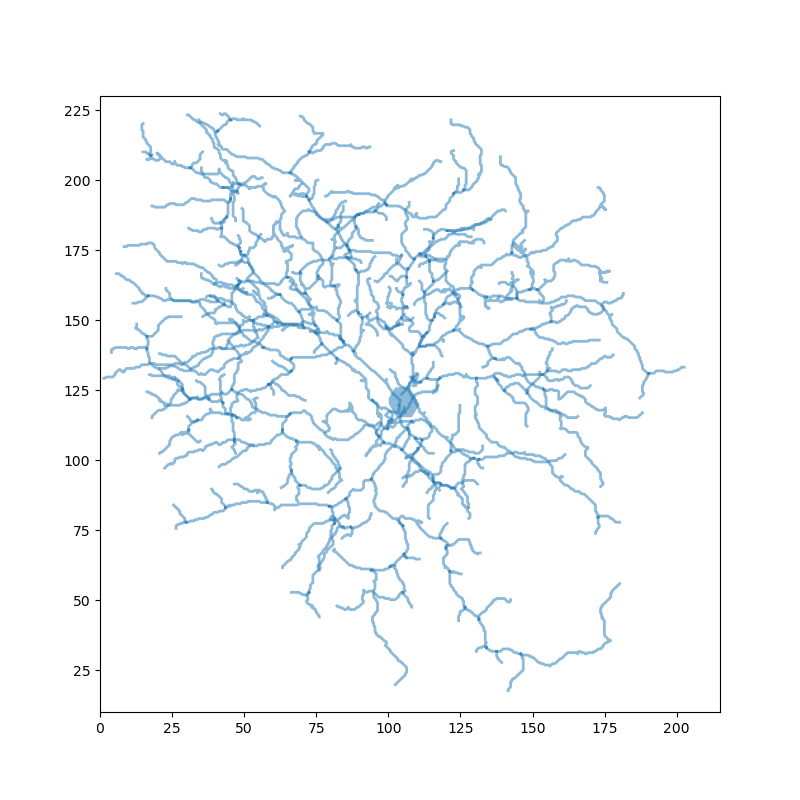

In [31]:
diam_mode = "fixed"  # "lw" | "3d" | "model" | "fixed"
dend_lw = 1.0        # used for "lw" diam_mode (regular ax.plot, axis units)
fixed_diam = 1.0     # used for "fixed" diam_mode (data unit lw)
dsgc_paths_fig, dsgc_paths_ax = plt.subplots(1, figsize=(8, 8))

dsgc_img, extent = get_dsgc_img()
# dsgc_paths_ax.imshow(dsgc_img, extent=extent, alpha=0.5, cmap="gray")
offset_x = 0
offset_y = 0
dsgc_paths_ax.fill(sec_pts[0][:, 0] + offset_x, sec_pts[0][:, 1] + offset_y, alpha=0.5)
dend_lines = []
for pts, diam in zip(sec_pts[1:], sec_diams[1:]):
    if diam_mode == "lw":
        dsgc_paths_ax.plot(pts[:, 0] + offset_x, pts[:, 1] + offset_y, lw=dend_lw, alpha=0.5)
    else:
        lw = fixed_diam if diam_mode == "fixed" else (pts[0, 3] if diam_mode == "3d" else diam)
        dend_lines.append(LineDataUnits(pts[:, 0] + offset_x, pts[:, 1] + offset_y, alpha=0.5, linewidth=lw))
        dsgc_paths_ax.add_line(dend_lines[-1])
    
dsgc_paths_ax.set_xlim(0, 215)
dsgc_paths_ax.set_ylim(10, 230)

In [20]:
from shapely.geometry import Point
from shapely.geometry import LineString

In [21]:
get_pts = lambda sec: np.array([[sec.x3d(i), sec.y3d(i), sec.z3d(i)] for i in range(sec.n3d())])

def syn_distributer(soma, spacing):
    syn_xy = []  # xy columns (indexed by syn number) 
    syn_loc = [] # syn idx -> (sec_idx, fractional loc)
    def rec(parent, child_idx, rem_space):
        parent_ref = h.SectionRef(parent)
        if child_idx >= parent_ref.nchild():
            return
            
        child = parent_ref.child[child_idx]
        # dend names are formated as "DSGC[1].dend[17]" and the id corresponds to the index
        # in the rgc.dend list of all dendrites
        cid = int(child.name().split(".")[1][5:-1]) # don't (?) offset to accomodate 0th soma node
        path = LineString(get_pts(child))
        l = child.L  # NEURON section length, may not match the 3d points (path.length), but better for physiology?
        frac_step = spacing / l 
        first_loc = np.clip(spacing - rem_space, 0, None) / l
        if first_loc <= 1:
            locs = np.arange(int(np.floor((1 - first_loc) / frac_step)) + 1) * frac_step + first_loc
            for loc in locs:
                syn_loc.append((cid, loc))
                p = path.interpolate(loc, normalized=True)
                syn_xy.append([p.x, p.y])
            child_rem_space = (1 - locs[-1]) * l
        else:
            child_rem_space = spacing - rem_space - l
            
        rec(child, 0, child_rem_space)
        rec(parent, child_idx + 1, rem_space)

    rec(soma, 0, 0)
    return np.array(syn_xy).T, syn_loc
        
xy, loc = syn_distributer(soma, 3)

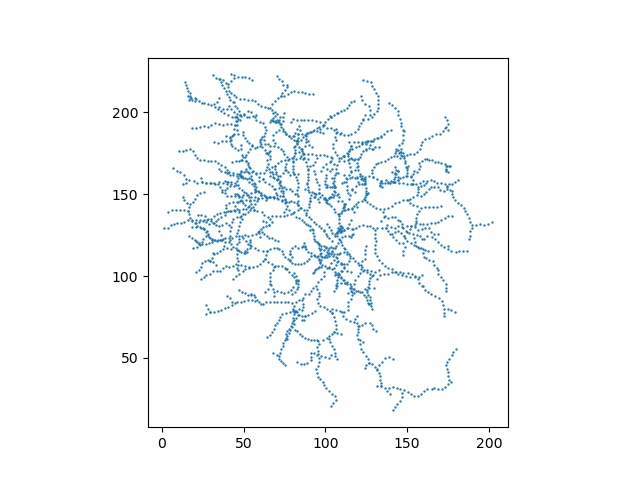

In [22]:
syn_scat_fig, syn_scat_ax = plt.subplots(1)
syn_scat_ax.set_aspect("equal")
syn_scat_ax.scatter(*xy, s=0.5)

In [23]:
pts

array([[ 16.25979996, 139.7460022 ,  36.        ,   0.5       ],
       [ 16.25979996, 139.7460022 ,  36.        ,   0.5       ],
       [ 15.8203001 , 140.18600464,  36.        ,   0.5       ],
       [ 15.38090038, 140.18600464,  36.        ,   0.5       ],
       [ 14.94139957, 140.18600464,  36.        ,   0.5       ],
       [ 14.50199986, 140.18600464,  36.        ,   0.5       ],
       [ 14.0625    , 140.18600464,  36.        ,   0.5       ],
       [ 13.62300014, 140.18600464,  36.        ,   0.5       ],
       [ 13.18360043, 140.18600464,  36.        ,   0.5       ],
       [ 12.74409962, 139.7460022 ,  35.        ,   0.5       ],
       [ 12.3046999 , 139.7460022 ,  35.        ,   0.5       ],
       [ 11.86520004, 139.7460022 ,  35.        ,   0.5       ],
       [ 11.42580032, 140.18600464,  35.        ,   0.5       ],
       [ 10.98630047, 140.18600464,  35.        ,   0.5       ],
       [ 10.5468998 , 140.18600464,  35.        ,   0.5       ],
       [ 10.10739994, 139

In [24]:
pts.shape

(32, 4)

In [25]:

# lstr = LineString(pts[:, :2])
lstr = LineString([[0, 0], [0, 2], [0, 6]])

In [26]:
# mpts.interpolate(3, normalized=False)
lstr.interpolate(0.5, normalized=True).xy

(array('d', [0.0]), array('d', [3.0]))

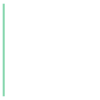

In [27]:
lstr